# Graph End-to-End Test Notebook

Use this notebook to invoke the compiled graph from `src/graph/graph.py` and verify the full workflow from supervisor routing through agent nodes, auto-ticket creation, and synthesizer output.

The notebook passes the required checkpoint configuration keys so the graph can execute with the SQLite checkpointer used by this repo.

In [1]:
import sys
from pathlib import Path
from pprint import pprint

# Ensure repo root is on sys.path when running from src/graph_test.ipynb
notebook_dir = Path.cwd()
repo_root = notebook_dir.parent if notebook_dir.name == 'src' else notebook_dir
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

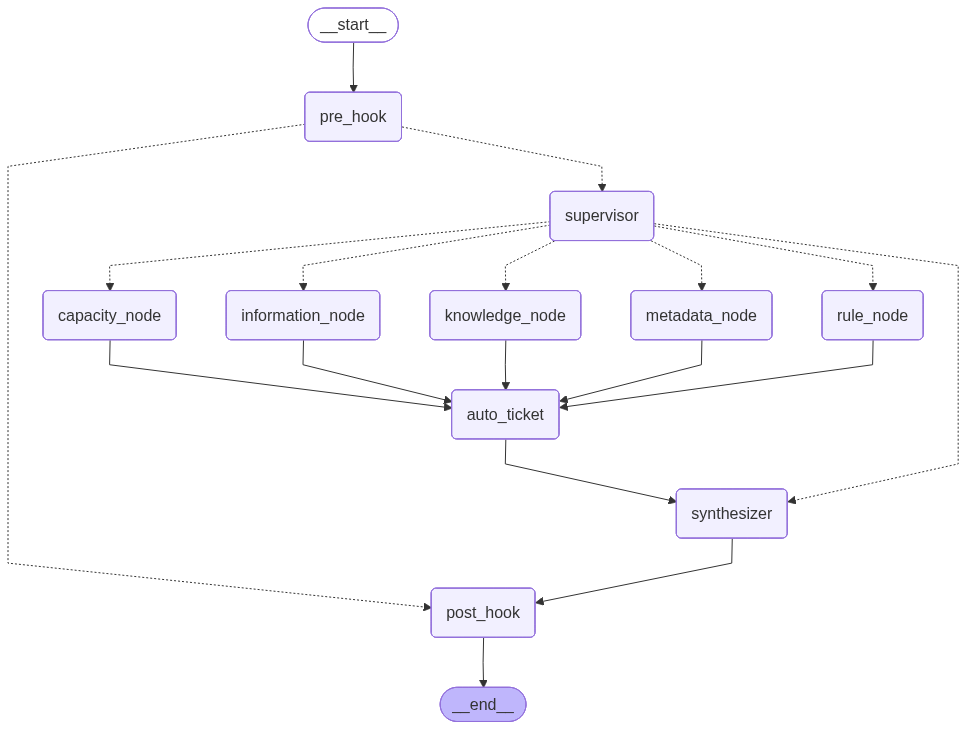

In [3]:

from graph.graph import build_graph, copilot_graph
from graph.state import initial_state
from graph.routing import INTENT_AGENT_MAP

GRAPH = copilot_graph if 'copilot_graph' in globals() else build_graph()
GRAPH

In [3]:

def run_graph(query: str, time_range: str = 'last_month',
              data_products=None, thread_id: str = 'notebook_test',
              user_id: str = 'notebook_user'):
    state = initial_state(
        query=query,
        thread_id=thread_id,
        user_id=user_id,
        time_range=time_range,
    )
    if data_products is not None:
        state['data_products'] = data_products
    config = {'configurable': {'thread_id': thread_id}}
    final_state = GRAPH.invoke(state, config=config)
    return final_state

In [4]:
print('Repo root:', repo_root)
print('Graph compiled:', GRAPH is not None)
print('Intent routing map:')
for intent, agents in INTENT_AGENT_MAP.items():
    print(f' - {intent}: {agents}')

Repo root: d:\0_PROJECTS\data-governance-copilot
Graph compiled: True
Intent routing map:
 - full_diagnostic: ['information', 'knowledge', 'metadata', 'capacity']
 - data_quality: ['metadata', 'information']
 - governance: ['metadata', 'knowledge']
 - incident_review: ['capacity']
 - knowledge_lookup: ['knowledge', 'metadata']
 - metric_analysis: ['information', 'knowledge']
 - write_ticket: ['capacity']
 - write_metadata: ['metadata']
 - write_rule: ['rule']
 - unknown: ['information', 'knowledge']


In [6]:
# Change these values and rerun this cell to test different full-graph scenarios.
selected_query = 'Why did retention drop in the last month?'
selected_time_range = 'last_month'
selected_data_products = ['retention']
selected_thread_id = 'graph_test_01'
selected_user_id = 'notebook_user'


print('Selected query:', selected_query)
print('Selected time range:', selected_time_range)
print('Selected data products:', selected_data_products)
print('Selected thread id:', selected_thread_id)
print('Selected user id:', selected_user_id)

Selected query: Why did retention drop in the last month?
Selected time range: last_month
Selected data products: ['retention']
Selected thread id: graph_test_01
Selected user id: notebook_user


In [ ]:
result = run_graph(
    selected_query,
    time_range=selected_time_range,
    data_products=selected_data_products,
    thread_id=selected_thread_id,
    user_id=selected_user_id,
)

q: why did retention drop in the last month?
QueryIntent.WRITE_TICKET ['create ticket', 'create a bug', 'open bug', 'raise issue', 'log incident', 'file a ticket']
QueryIntent.WRITE_METADATA ['update owner', 'set owner', 'update metadata', 'classify', 'update description']
QueryIntent.WRITE_RULE ['create rule', 'add rule', 'define rule', 'new rule', 'create dq rule']
QueryIntent.FULL_DIAGNOSTIC ['why did', 'root cause', 'investigate', 'explain why', 'diagnose', 'what happened']
intent.value: full_diagnostic
[16:35:58] INFO     agent.information_agent | [985501b3] information_agent received: 'Why did retention drop in the last month?'
[16:35:58] INFO     agent.knowledge_agent | [985501b3] knowledge_agent received: 'Why did retention drop in the last month?'
[16:35:58] INFO     agent.metadata_agent | [985501b3] metadata_agent received: 'Why did retention drop in the last month?'
[16:35:58] INFO     agent.capacity_agent | [985501b3] capacity_agent received: 'Why did retention drop in the 

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [8]:
print('--- Graph Result ---')
print('Final summary:')
print(result.get('final_summary'))
print('Confidence:', result.get('confidence'))
print('Next agents:', result.get('next_agents'))
print('Agent results count:', len(result.get('agent_results', [])))
print('Auto tickets:', result.get('auto_tickets'))
print('Sources:', result.get('sources'))
print('Execution ms:', result.get('execution_ms'))
print('--- Full state ---')
pprint(result)

--- Graph Result ---
Final summary:
📊 **Metrics Summary** (last_month)

**RETENTION**
  • Gross Retention Rate: 83.22
  • Gross Retention Prev: 87.3
  • Net Retention Rate: 108.59
  • Churn Rate: 16.78
  • Churned Accounts: 19
  • Total Accounts: 412
  • At Risk Accounts: 24

**🚨 Anomalies:**
  ⚠️ GRR (83.22%) below 85% threshold — investigate churn drivers immediately.

---

📚 **Business Context**

**RETENTION**
  _Definition:_ Gross Retention Rate (GRR) measures the percentage of recurring revenue retained from existing customers, excluding expansion. Net Retention Rate (NRR) includes upsells. Benchmarks: GRR >85% (SMB), >90% (Enterprise).
  _Context:_ Retention declines in Q3 2024 were attributed to: (1) product gaps in the reporting module cited in 34% of churn surveys, (2) competitive displacement by Vendor X in SMB, (3) a 2-week SLA breach in EU affecting 12 accounts.
  _Reference:_ See: Retention Recovery Playbook v2.1 (SharePoint/CS/Playbooks/)

---

🏛️ **Governance & Metadata*

## Sample queries for targeted graph paths

Use these query examples to exercise different agent combinations via the supervisor routing logic.

- `Why did retention drop?` → full diagnostic (`information`, `knowledge`, `metadata`, `capacity`)
- `Show governance metadata for retention` → governance path (`metadata`, `knowledge`)
- `List open issues for retention` → incident review / capacity-only path
- `What is GRR and why does it matter?` → knowledge lookup
- `What is the current retention trend?` → metric analysis (`information`, `knowledge`)
- `Create a rule for retention threshold` → rule path
- `Create ticket for missing retention pipeline data` → write ticket path

If the graph fails, verify that the `thread_id` in the config is provided and that the notebook is running from `src/graph_test.ipynb`.